## Hartman-Grobman Theorem
$\newcommand{\xstar}{x^{\star}}$
$\newcommand{\R}{{\Bbb R}}$
https://en.wikipedia.org/wiki/Hartman–Grobman_theorem

### Hypotheses
1. Let $U$ be an **open neighborhood** of $x^{\star}$ in ${\Bbb R}^n$.  That is $U$ is open (all points of $U$ are interior points) and contains $x^{\star}$.

2. Let $f:U\to{\Bbb R}^n$ be $C^{1}$ on $U$ (continuous partial derivatives of the components w.r.t. the usual coordinates).

3. Let $J$ be the Jacobian matrix
$$
    J = [J_{ij}] = [\partial f_i/\partial x_j].
$$

4. Let $\phi(t,y_0)=\phi^t(y_0)=\phi_{y_0}(t)$ be the **flow** for 
\begin{equation}
    \dot y = f(y),\qquad y(0)=y_0. \tag{IVP}
\end{equation}
That is, for each initial condition $y_0\in U$, $\phi_{y_0}(t)$ satisfies (IVP) on some open interval about $t=0$. 

5. Suppose $x^{\star}$ is an **equilibrium point** (or **fixed point**) for $f$.  That is, $f(x^{\star})=0$ hence
$$
    \phi(t,x^{\star}) \equiv x^{\star}.
$$

6. Suppose $A=J(x^{\star})$ is **hyperbolic**.  That is, all eigenvalues of $A$ have nonzero real part.

### Conclusion
#### Then
1. there is a **neighborhood** $N$ of $x^{\star}$ (a set with $x^{\star}$ in its interior), 

2. a neighborhood $V$ of $0$ in ${\Bbb R}^n$, and

3. a **homeomorphism** $h:N\to V$, that is $h$ is continuous, invertible, and its inverse is continuous

#### such that
* under the change of coordinates $x=h(y)$ the flow $\phi$ is topologically conjugate to the flow for the linear system
$$
    \dot x = Ax\qquad x(t_0) = x_0
$$
which as we now know is $e^{At}x_0$.  That is, $h(\phi(t,y_0))=e^{At}x_0$ with $x_0=h(y_0)$.

## Linear Systems in ${\Bbb R}^2$.

Two distinct real eigenvalues (or one of geometric multiplicity two).
$$
    J_1 = \begin{bmatrix} \lambda_1 & 0 \cr 0 & \lambda_2 \end{bmatrix}
$$

A complex congjugate pair of eigenvalues
$$
    J_2 = \begin{bmatrix} \alpha & \beta \cr -\beta & \alpha \end{bmatrix}
$$

Exactly one eigenvalue of geometric multiplicity one
$$
    J_3 = \begin{bmatrix} \lambda_1 & 1 \cr 0 & \lambda_1 \end{bmatrix}
$$

## Pendulum problem, ignoring friction
Total energy
$$
    E = -mg\ell\cos\theta + {1\over 2} m \ell^2(\dot\theta)^2
$$

conservation of energy implies
$$
        0 = mg\ell \sin\theta \dot\theta + m\ell^2\dot\theta\ddot\theta
$$

or
$$
    \ddot\theta =-{g\over\ell}\sin\theta
$$

## Friction included
$$
    \ddot\theta =-{g\over\ell}\sin\theta - 2\alpha \dot\theta
$$

$x_1=\theta$, $x_2=\dot\theta$

\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\frac{g}{\ell}\sin(x_1) - 2\alpha x_2\cr
\end{align}

## Imports

In [1]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.integrate import solve_ivp

## Functions and parameters

In [4]:
g,ℓ = 9.81,1.0
α = 0.

# Energy divided by m\ell
f = lambda x1, x2: -2*g*np.cos(x1) + ℓ*x2**2

def pend(t,xx):
    x1, x2 = xx
    return [x2,-g*math.sin(x1)/ℓ-2*α*x2]

J = lambda x1, x2: np.array([[0,1],[-(g/ℓ)*np.cos(x1),-2*α]])

In [5]:
J(0,0)

array([[ 0.  ,  1.  ],
       [-9.81, -0.  ]])

In [6]:
LA.eig(J(0,0))[0]

array([ 0.+3.13209195j, -0.-3.13209195j])

In [7]:
J(π,0)

array([[ 0.  ,  1.  ],
       [ 9.81, -0.  ]])

In [9]:
LA.eig(J(π,0))[0]

array([ 3.13209195, -3.13209195])

## Conservation of energy gives us solution curves. 

$$
    E = -mg\ell\cos\theta + {1\over 2} m \ell^2(\dot\theta)^2
$$
so
$$
    f = -2g\cos x_1  + \ell x_2^2
$$
is conserved.  Solutions are constrained to the level curves for this function.

## Region of study
The restrictions
$$
    a\le x_1 \le b \quad c\le x_2 \le d
$$
define a rectangular region $R$.

In [21]:
a,b = -π-1,π+1 # x limits
c,d = -6,6     # y limits
npts = 100
x1 = np.linspace(a,b,npts)
x2 = np.linspace(c,d,npts)
X1,X2 = np.meshgrid(x1,x2)
#X1

In [22]:
Z = f(X1,X2)
#Z

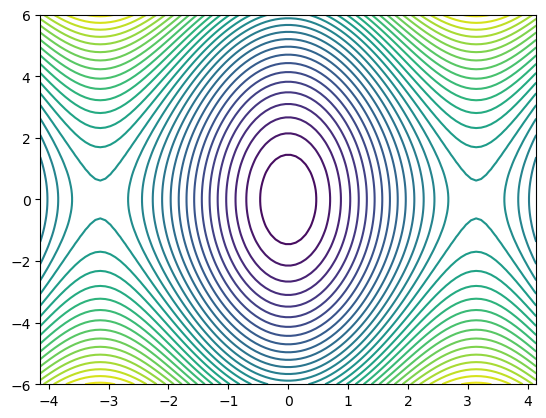

In [23]:
#help(plt.contour)
plt.contour(X1,X2,Z,levels=30)

## Time interval and Initial Conditions
$$
    (x_{10},x_{20})\in R,\qquad t_0\le t\le t_1
$$

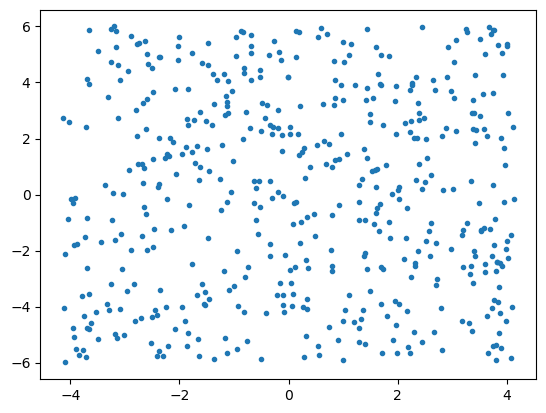

In [25]:
#help(solve_ivp)
t0,t1 = 0.,20.
Nsols = 500
x10s = (b-a)*np.random.rand(Nsols)+a
x20s = (c-d)*np.random.rand(Nsols)+d
x1x20s = np.vstack((x10s,x20s)).T
t_span = [t0,t1]
plt.plot(x10s,x20s,'.')

## Test solution

In [26]:
y0 = np.array([π/4,0.])
sol = solve_ivp(pend,t_span,y0)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.440e-04 ...  1.977e+01  2.000e+01]
        y: [[ 7.854e-01  7.854e-01 ... -7.723e-01 -6.328e-01]
            [ 0.000e+00 -9.987e-04 ... -1.559e-01  1.339e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 470
     njev: 0
      nlu: 0

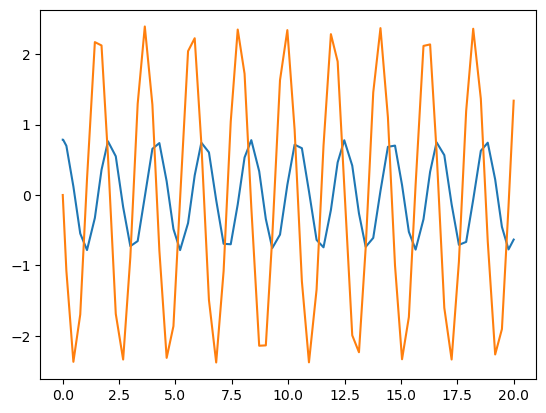

In [27]:
plt.plot(sol.t,sol.y.T)

In [28]:
tsteps = 500
t_eval = np.linspace(t0,t1,tsteps+1)
sol = solve_ivp(pend,t_span,y0,t_eval=t_eval)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.000e-02 ...  1.996e+01  2.000e+01]
        y: [[ 7.854e-01  7.799e-01 ... -6.816e-01 -6.328e-01]
            [ 0.000e+00 -2.770e-01 ...  1.099e+00  1.339e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 470
     njev: 0
      nlu: 0

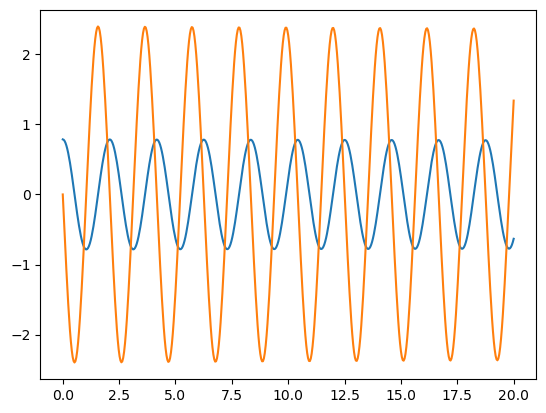

In [29]:
plt.plot(sol.t,sol.y.T)

In [30]:
%%time
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

CPU times: user 4.36 s, sys: 13.6 ms, total: 4.38 s
Wall time: 4.38 s


In [31]:
%matplotlib notebook

<IPython.core.display.Javascript object>


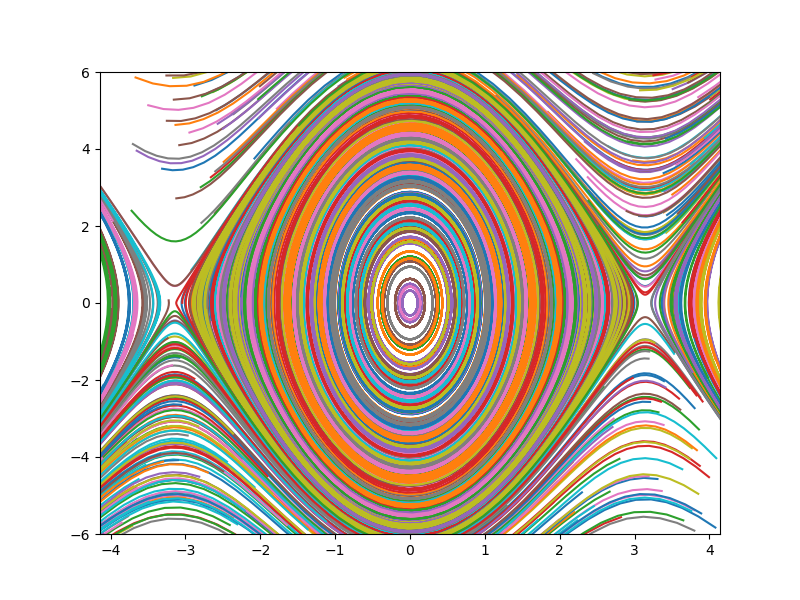

In [33]:
fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

In [34]:
α = 0.1
LA.eig(J(0,0))[0]

array([-0.1+3.13049517j, -0.1-3.13049517j])

<IPython.core.display.Javascript object>


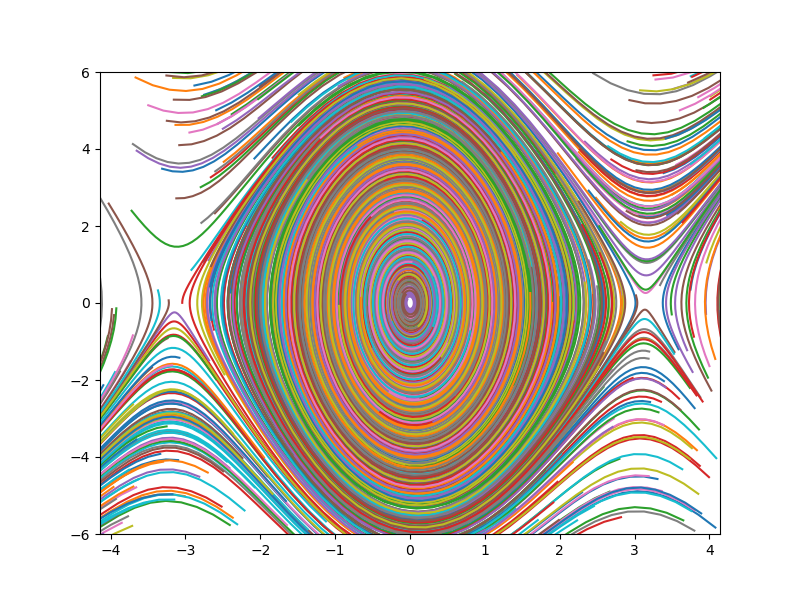

In [35]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

In [36]:
α = 1.
LA.eig(J(0,0))[0]

array([-1.+2.96816442j, -1.-2.96816442j])

<IPython.core.display.Javascript object>


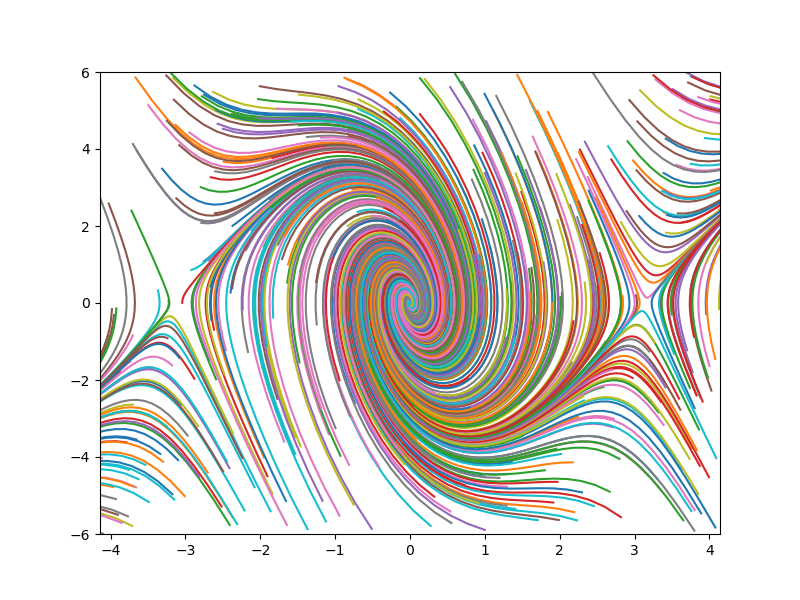

In [37]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

In [38]:
α = 3.
LA.eig(J(0,0))[0]

array([-3.+0.9j, -3.-0.9j])

<IPython.core.display.Javascript object>


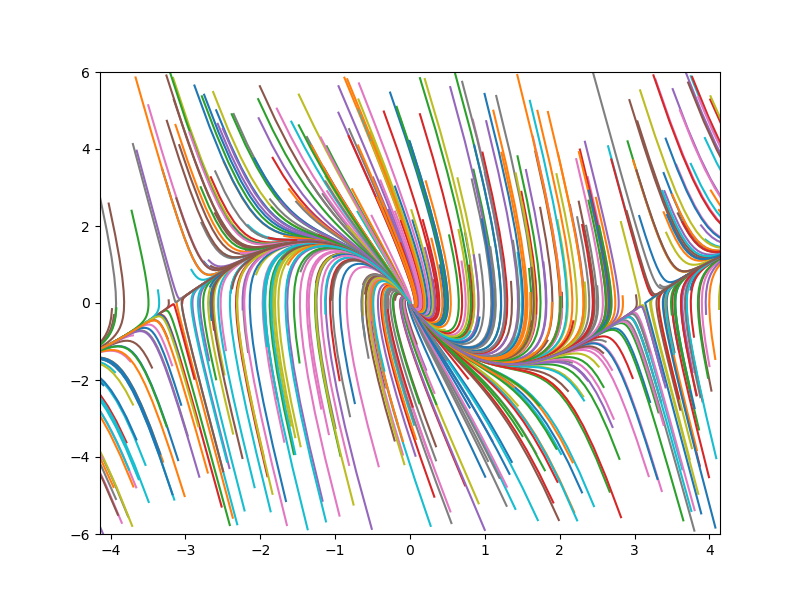

In [39]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

In [40]:
α = 3.132092
LA.eig(J(0,0))[0]

array([-3.13154751, -3.13263649])

<IPython.core.display.Javascript object>


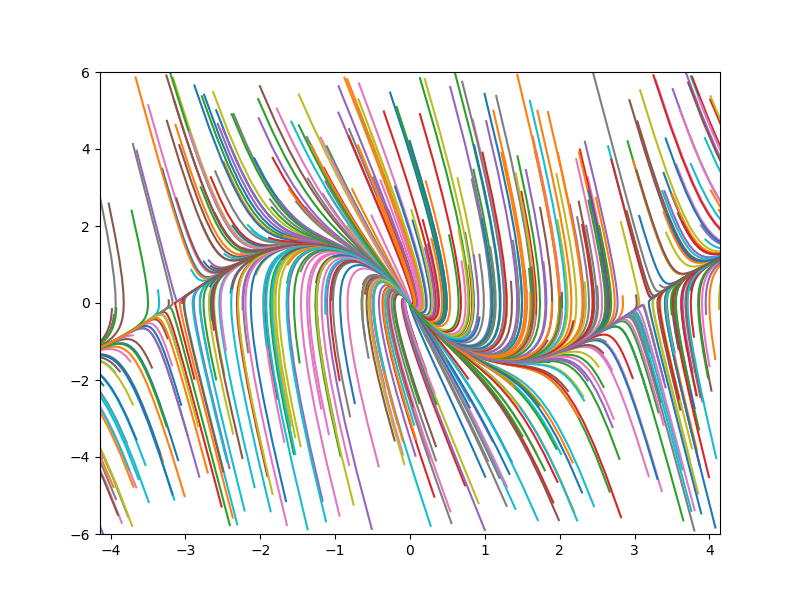

In [41]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()

In [48]:
α = 0.1
ε = 1e-1
def pend(t,xx):
    x1, x2 = xx
    return ε*np.random.randn(2) + [x2,-g*math.sin(x1)/ℓ-2*α*x2]

<IPython.core.display.Javascript object>


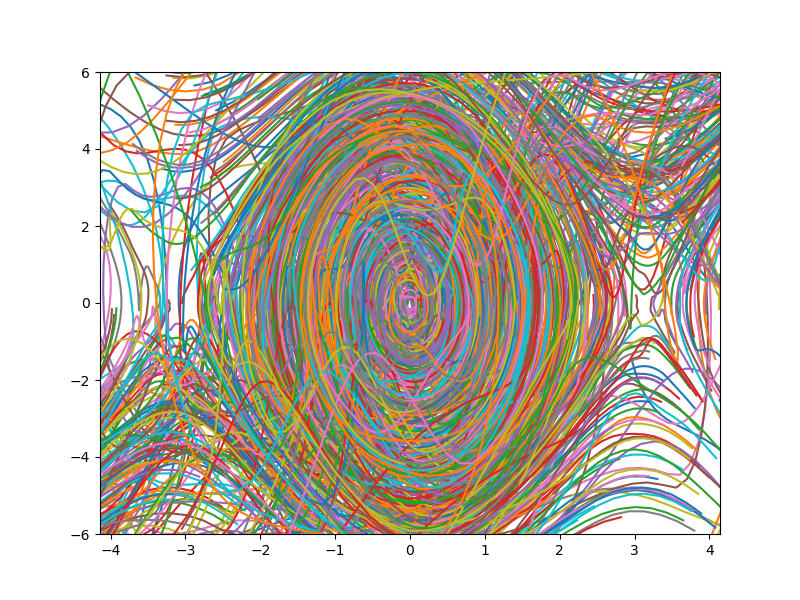

In [50]:
sols = []
for x10x20 in x1x20s:
    sol = solve_ivp(pend,t_span,x10x20,t_eval=t_eval,rtol=ε)
    sols.append(sol)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,tsteps+1),
                    init_func=init, blit=True)
plt.show()